# Reliability-based Design

Reliability-based design is concerned with mitigating risk to failure under uncertainty of design variables or parameters. In this case, the designer is concerned with lowering the probability that the constraints are violated under uncertainty of the design variables and parameters. In other words, reliable design considers the effect of uncertainty on the constraints. For a reliable design, the deterministic constraints of the optimization problem are changed to ensure that the probability of feasibility of the constraint exceeds a specified reliability level $r$.

$$\text{Pr}(g(\textbf{x})\leq0) \geq r$$

If $r$ is set to 0.999, then the constraint must be feasible with a probability of 99.9%. 

To illustrate the idea of reliability-based design, consider the following constrained optimization problem. The deterministic optimum solution of this problem is $f^* = -3.52341$ at $x_1 = 1.06237$ and $x_2 = 2.12086$.

$$
\begin{align}
    \min \; &f(x_1,x_2) = x_1^2 - \frac{x_1}{2} - x_2 - 2 \nonumber\\
    \text{subject to} & \nonumber\\
    g_1(x_1,x_2) &= x_1^2 -4x_1 + x_2 + 1  \leq 0 \nonumber\\
    g_2(x_1,x_2) &= \frac{x_1^2}{2} + x_2^2 - x_1 - 4 \leq 0 \nonumber\\
    &-3 \leq x_1 \leq 5, \quad -3 \leq x_2 \leq 4 \nonumber\\
\end{align}
$$

The block of code below imports the necessary packages for this section.

In [34]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.optimize import minimize
from pymoo.config import Config
Config.warnings['not_compiled'] = False

The block of code below defines the objective and constraint functions of the problem. It also plots the design space with constraint and objective functions along with the deterministic optimum point. The shaded region in the plot marks the infeasible part of the design space. 

Note that the deterministic optimum point lies at the boundary of both the constraints. Any variation in the constraints can make the point infeasible.

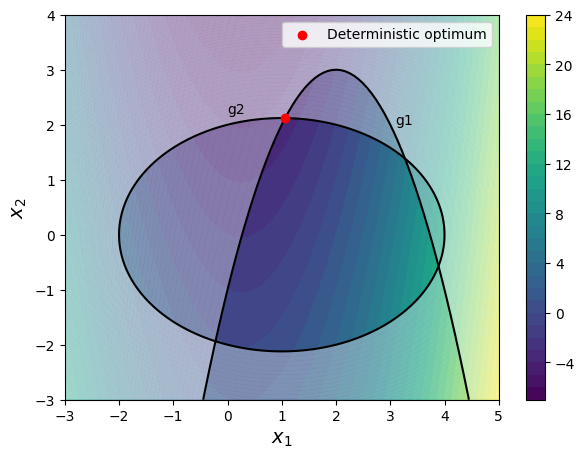

In [35]:
# Functions for fast computations
function_2 = lambda x1, x2: x1**2 - x1/2 - x2 - 2
constraint_1 = lambda x1, x2: x1**2 - 4*x1 + x2 + 1
constraint_2 = lambda x1, x2: x1**2 / 2 + x2**2 - x1 - 4

# Function for optimization
obj = lambda x: function_2(x[0],x[1])

# Defining x and y values
x = np.linspace(-3,5,100)
y = np.linspace(-3,4,100)

# Creating a mesh at which values
# will be evaluated and plotted
X, Y = np.meshgrid(x, y)

# Evaluating the function values at meshpoints
Z = function_2(X,Y)
g1 = constraint_1(X,Y)
g2 = constraint_2(X,Y)

# Plotting the filled contours
fig, ax = plt.subplots(figsize=(7,5))
CS = ax.contourf(X, Y, Z, levels=30)
fig.colorbar(CS, orientation='vertical')

# Plotting g1
ax.contour(X, Y, g1, levels=[0], colors="k")
ax.contourf(X, Y, g1, levels=np.linspace(0,g1.max()), colors="white", alpha=0.35, antialiased = True)
ax.annotate('g1', xy =(3.1, 2.0))

# Plotting g2
ax.contour(X, Y, g2, levels=[0], colors="k")
ax.contourf(X, Y, g2, levels=np.linspace(0,g2.max()), colors="white", alpha=0.35, antialiased = True)
ax.annotate('g2', xy =(0.0, 2.2))

# Optimum point
det_opt_x1 = 1.06237
det_opt_x2 = 2.12086
ax.scatter(det_opt_x1, det_opt_x2, c="r", label="Deterministic optimum", zorder=10)

# Asthetics
ax.set_xlabel("$x_1$", fontsize=14)
ax.set_ylabel("$x_2$", fontsize=14)
ax.legend()

## Probability of feasibility of a constraint

The probability of feasibility of a constraint is of central interest when performing reliability-based design. The probability of feasibility of the constraints from the example problem can be calculated using MCS. The distributions of the uncertain variables can be sampled using the methods shown in the uncertainty analysis section and for each sample, the value of the constraint can be calculated. Once all the samples are evaluated, the required probability can be calculated by simply dividing the number of samples that satisfy the constraint by the total number of samples.

$$\text{Pr}(g(\textbf{x}) \leq 0) \approx \frac{\text{number of feasible samples}}{\text{total number of samples}}$$

For this example of reliability-based design, consider $x_1$ and $x_2$ to be uncertain variables that follow **normal distributions** with $\sigma_1 = 0.1$ and $\sigma_2 = 0.2$.

$$x_1 \sim \mathcal{N}(1.06237, 0.1^2), \quad x_2 \sim \mathcal{N}(2.12086, 0.2^2) $$

The next block of code uses random sampling and a large number of MCS samples to calculate the true probability of feasibility of the constraints.

In [36]:
# Standard deviation for both variables
x1_sigma = 0.1
x2_sigma = 0.2

# Number of MCS iterations
mcs_samples = 500000

# Generate random samples
x1 = norm(loc=det_opt_x1, scale=x1_sigma).rvs(size=mcs_samples)
x2 = norm(loc=det_opt_x2, scale=x2_sigma).rvs(size=mcs_samples)

# Compute value of constraints at those x values
g1_value = constraint_1(x1, x2)
g2_value = constraint_2(x1, x2)

# Compute probability of feasibility for both constraints
# It involves counting how many values satisfy the 
# constraints and compute the fraction.
pf_g1 = len(g1_value[g1_value <= 0])/mcs_samples
pf_g2 = len(g2_value[g2_value <= 0])/mcs_samples

# Printing the results
print(f"Estimated probability of feasibility for g1: {len(g1_value[g1_value<=0])/mcs_samples}")
print(f"Estimated probability of feasibility for g1: {len(g2_value[g2_value<=0])/mcs_samples}")

Estimated probability of feasibility for g1: 0.49292
Estimated probability of feasibility for g1: 0.49818


The above calculations indicate that the deterministic optimum point has a probability of feasibility of nearly 0.50. This means that given the uncertainty in the design variables, the constraint will be infeasible almost half of the time. Hence, there is a need for reliability-based optimization to prevent the constraint from being violated under uncertainty. The optimization problem statement for reliability-based design will be as follows. 

$$
\begin{align}
    \min \; &f(x_1,x_2) = x_1^2 - \frac{x_1}{2} - x_2 - 2 \nonumber\\
    \text{subject to} & \nonumber\\
    &P[g_1(x_1, x_2) \leq 0] \geq 0.99 \nonumber\\
    &P[g_2(x_1, x_2) \leq 0] \geq 0.99 \nonumber\\
    &-3 \leq x_1 \leq 5, \quad -3 \leq x_2 \leq 4 \nonumber\\
\end{align}
$$

> __NOTE__: The objective function of the problem is kept deterministic in this case. However, the objective function can also be changed to a robust design objective to perform a combination of robust and reliability-based design. 

The block of code below defines two functions for computing the reliability for each constraint.

In [37]:
# Few parameters
x1_sigma = 0.1
x2_sigma = 0.2
mcs_samples = 500000
reliability = 0.99

def rel_con1(x):
    """
        Function for computing reliability of g1.
    """
    
    # Generate random samples
    x1 = norm(loc=x[0], scale=x1_sigma).rvs(size=mcs_samples)
    x2 = norm(loc=x[1], scale=x2_sigma).rvs(size=mcs_samples)
    
    # Compute value of constraint at those x values
    g1_value = constraint_1(x1, x2)
    
    # Computing frequency of feasible x
    return reliability - len(g1_value[g1_value <= 0])/mcs_samples

def rel_con2(x):
    """
        Function for computing reliability of g2.
    """
    
    # Generate random samples
    x1 = norm(loc=x[0], scale=x1_sigma).rvs(size=mcs_samples)
    x2 = norm(loc=x[1], scale=x2_sigma).rvs(size=mcs_samples)
    
    # Compute value of constraint at those x values
    g2_value = constraint_2(x1, x2)
    
    # Computing frequency of feasible x
    return reliability - len(g2_value[g2_value <= 0])/mcs_samples

The block of code below performs reliability-based optimization.

Here, *differential evolution* (DE) is used as an optimizer. As explained earlier, gradient-based optimizers don't work well since gradients can be difficult to compute. Since DE involves lots of function evaluations and at each iteration, MCS is performed several times, the optimization will take longer to run.

In [38]:
# Defining a generic differential evolution problem
class ReliableDesign(ElementwiseProblem):

    def __init__(self):
        super().__init__(n_var=2, n_obj=1, n_ieq_constr=2, xl=np.array([-3,-3]), xu=np.array([5,4]))

    def _evaluate(self, x, out, *args, **kwargs):
        out["F"] = function_2(x[0],x[1])
        out["G"] = np.column_stack((rel_con1(x), rel_con2(x)))

problem = ReliableDesign()

algorithm = DE(pop_size=20, CR=0.8, dither="vector")

In [39]:
res = minimize(problem, algorithm, verbose=False, save_history=True)

print("Best solution found: \nX = %s\nF = %s" % (res.X, res.F))

rel_opt_x1 = res.X[0]
rel_opt_x2 = res.X[1]

Best solution found: 
X = [1.15608742 1.65134853]
F = [-2.89285412]


In [40]:
mcs_samples = 500000

# Sample the input distributions
x1 = norm(loc=rel_opt_x1, scale=x1_sigma).rvs(size=mcs_samples)
x2 = norm(loc=rel_opt_x2, scale=x2_sigma).rvs(size=mcs_samples)

# Compute value of constraints at those x values
g1_value = constraint_1(x1, x2)
g2_value = constraint_2(x1, x2)

# Compute probability of feasibility
pf_g1 = len(g1_value[g1_value <= 0])/mcs_samples
pf_g2 = len(g2_value[g2_value <= 0])/mcs_samples

# Printing the results
print(f"Probability of feasibility for g1: {len(g1_value[g1_value<=0])/mcs_samples}")
print(f"Probability of feasibility for g1: {len(g2_value[g2_value<=0])/mcs_samples}")

Probability of feasibility for g1: 0.989554
Probability of feasibility for g1: 0.990106


The design point obtained using reliability-based design ihas a much higher reliability as compared to the deterministic optimum. However, the value of the objective function at the optimum value is also increased. The block of code below plots the design space with both the deterministic and reliable optimum. The reliability value can be changed to see how the optimum point changes.

The plot also shows the uncertainty ellipse around the reliable optimum. The uncertainty ellipse essentially shows the spread of 99% of the possible values of the uncertain design variables. The shape of the ellipse shows that the probability of constraint violation is greatly reduced after accounting for the uncertainty in the design variables. This is because there is a smaller portion of the ellipse that falls in the infeasible region of the problem. This ellipse would change to a circle if the standard deviation of both the design variables was the same. 

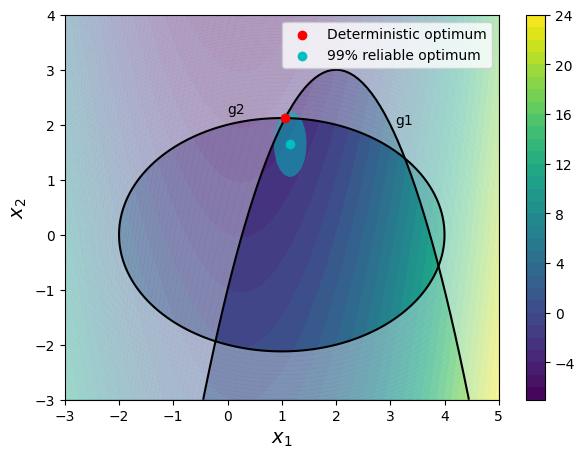

In [41]:
# Defining x and y values
x = np.linspace(-3,5,100)
y = np.linspace(-3,4,100)

# Creating a mesh at which values
# will be evaluated and plotted
X, Y = np.meshgrid(x, y)

# Evaluating the function values at meshpoints
Z = function_2(X,Y)
g1 = constraint_1(X,Y)
g2 = constraint_2(X,Y)

# Calculating quantities for plotting uncertainty ellipse
n_std = 3.0
cov = np.cov(x1, x2)
pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
ell_radius_x = np.sqrt(1 + pearson)
ell_radius_y = np.sqrt(1 - pearson)
ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, facecolor = "c", alpha=0.5, antialiased = True)

scale_x1 = np.sqrt(cov[0, 0]) * n_std
mean_x1 = np.mean(x1)
scale_x2 = np.sqrt(cov[1, 1]) * n_std
mean_x2 = np.mean(x2)

transf = transforms.Affine2D() \
    .scale(scale_x1, scale_x2) \
    .translate(mean_x1, mean_x2)

# Plotting the filled contours
fig, ax = plt.subplots(figsize=(7,5))
CS = ax.contourf(X, Y, Z, levels=30)
fig.colorbar(CS, orientation='vertical')

# Plotting g1
ax.contour(X, Y, g1, levels=[0], colors="k")
ax.contourf(X, Y, g1, levels=np.linspace(0,g1.max()), colors="white", alpha=0.35, antialiased = True)
ax.annotate('g1', xy =(3.1, 2.0))

# Plotting g2
ax.contour(X, Y, g2, levels=[0], colors="k")
ax.contourf(X, Y, g2, levels=np.linspace(0,g2.max()), colors="white", alpha=0.35, antialiased = True)
ax.annotate('g2', xy =(0.0, 2.2))

# Optimum point
ax.scatter(det_opt_x1, det_opt_x2, c="r", label="Deterministic optimum", zorder=10)
ax.scatter(rel_opt_x1, rel_opt_x2, c="c", label="99% reliable optimum", zorder=10)

# Plotting uncertainty ellipse
ellipse.set_transform(transf + ax.transData)
ax.add_patch(ellipse)

# Asthetics
ax.set_xlabel("$x_1$", fontsize=14)
ax.set_ylabel("$x_2$", fontsize=14)
ax.legend()